# 🛡️ GraphSentinel — Unified Training Notebook
## Self-Healing Cyber Defense via GraphSAGE Node Classification

**Project:** GraphSentinel | **Role:** ML / GNN Engineer | **Author:** Sathvik  
**Platform:** Google Colab (T4 / A100) | **Framework:** PyTorch 2.4 + PyG 2.5

---

### Problem Statement
Train a **GraphSAGE** model to classify network nodes as *Benign (0)* or *Malicious (1)*  
from CICIDS2017 flow data, targeting 5 attack types: DDoS, PortScan, Botnet, SSH-Patator, DoS Hulk.

### Architecture Summary
- **Model:** `GraphSAGEClassifier` — 3-layer SAGEConv, hidden=256, out=2  
- **Input:** 7 handcrafted node features (frozen contract with backend)  
- **Dataset:** CICIDS2017 (Tuesday + Wednesday + Friday CSVs)  
- **Graph Construction:** Time-windowed flow aggregation → PyG `Data` objects  
- **Output:** `graphsage_weights.pt` + `scaler.pkl`

### Performance Targets
| Metric | Target |
|---|---|
| Accuracy | ≥ 92% |
| Weighted F1 | ≥ 0.88 |
| AUC-ROC | ≥ 0.95 |

### 🚀 Quick Start
1. Mount Drive → 2. Check dataset → 3. Run all cells top-to-bottom  
4. On crash: re-run from **Section 6 (Training)** — checkpoint auto-resumes

---
> ⚠️ **DO NOT change** `GraphSAGEClassifier` class name or default `in_channels=7`.  
> Sairaj's backend imports this class directly from `model.py`.


---
## Section 1 — Environment Setup
Install required packages, verify versions, configure reproducibility.


In [3]:
%%time
# Install PyTorch Geometric and required dependencies
# PyG wheels depend on torch version — auto-detect
import subprocess, sys

def run(cmd):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"WARN: {cmd}\n{result.stderr[:300]}")
    return result.stdout.strip()

# Core dependencies
print("Installing imbalanced-learn and networkx...")
run("pip install imbalanced-learn -q")
run("pip install networkx -q")
run("pip install scipy -q")

import torch
torch_version = torch.__version__
cuda_version  = torch.version.cuda or "cpu"
print(f"\nPyTorch version : {torch_version}")
print(f"CUDA version    : {cuda_version}")

# Install PyG matching current torch
torch_tag = torch_version.split("+")[0]  # strip +cu121 etc.
major_minor = ".".join(torch_tag.split(".")[:2])  # e.g. "2.4"
print(f"Installing torch-geometric for PyTorch {major_minor}...")

run("pip install torch-geometric -q")
run("pip install pyg-lib torch-scatter torch-sparse torch-cluster torch-spline-conv "
    "-f https://data.pyg.org/whl/torch-2.4.0+cu121.html -q")

# Verify PyG
try:
    import torch_geometric
    print(f"torch-geometric  : {torch_geometric.__version__}")
except ImportError:
    print("torch-geometric not installed — running plain install")
    run("pip install torch-geometric -q")

print("\n✅ Environment ready")


Installing imbalanced-learn and networkx...

PyTorch version : 2.11.0+cu128
CUDA version    : 12.8
Installing torch-geometric for PyTorch 2.11...


/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/libpyg.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_cluster/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sp

torch-geometric  : 2.7.0

✅ Environment ready
CPU times: user 10.5 s, sys: 2.03 s, total: 12.6 s
Wall time: 40.9 s


In [4]:
# ── Reproducibility & global seed ──────────────────────────────────────────
import os, random
import numpy as np
import torch

SEED = 42

def set_global_seed(seed: int = SEED):
    """Fix all random sources for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False   # Slightly slower but reproducible
    print(f"✅ Global seed set to {seed}")

set_global_seed(SEED)

# ── GPU check ────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice          : {device}")
if device.type == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU             : {gpu_name}")
    print(f"GPU Memory      : {gpu_mem:.1f} GB")
    print(f"CUDA Capability : {torch.cuda.get_device_capability(0)}")
else:
    print("⚠️  No GPU found — training will be slow on CPU")
    print("   Tip: Runtime → Change runtime type → GPU → T4")


✅ Global seed set to 42

Device          : cuda
GPU             : Tesla T4
GPU Memory      : 15.6 GB
CUDA Capability : (7, 5)


---
## Section 2 — Google Drive Mounting & Path Configuration
All paths are configured here. Change `DRIVE_BASE` if your folder structure differs.


In [1]:
!rm -rf /content/drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted")


Mounted at /content/drive
✅ Google Drive mounted


In [5]:
import os

# ── Path configuration — edit ONLY this block ────────────────────────────────
DRIVE_BASE    = "/content/drive/MyDrive/GraphSentinel/"
DATASET_PATH  = DRIVE_BASE + "datasets/cicids2017/"
MODEL_DIR     = DRIVE_BASE + "models/"
PROCESSED_DIR = DRIVE_BASE + "processed/"
LOG_DIR       = DRIVE_BASE + "logs/"
CHECKPOINT_DIR= DRIVE_BASE + "checkpoints/"

# ── Auto-create all directories ───────────────────────────────────────────────
for d in [MODEL_DIR, PROCESSED_DIR, LOG_DIR, CHECKPOINT_DIR]:
    os.makedirs(d, exist_ok=True)
    print(f"  ✓ {d}")

# ── Verify dataset directory exists ──────────────────────────────────────────
if os.path.isdir(DATASET_PATH):
    files_found = os.listdir(DATASET_PATH)
    print(f"\n✅ Dataset directory found ({len(files_found)} items):")
    for f in sorted(files_found)[:10]:
        size_mb = os.path.getsize(DATASET_PATH + f) / 1e6 if os.path.isfile(DATASET_PATH + f) else 0
        print(f"   {f:<60s} {size_mb:6.1f} MB")
else:
    print(f"\n❌ Dataset directory NOT found: {DATASET_PATH}")
    print("   Please upload CSVs to Google Drive and update DATASET_PATH above.")


  ✓ /content/drive/MyDrive/GraphSentinel/models/
  ✓ /content/drive/MyDrive/GraphSentinel/processed/
  ✓ /content/drive/MyDrive/GraphSentinel/logs/
  ✓ /content/drive/MyDrive/GraphSentinel/checkpoints/

✅ Dataset directory found (5 items):
   Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv               77.1 MB
   Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv           76.9 MB
   Friday-WorkingHours-Morning.pcap_ISCX.csv                      58.3 MB
   Tuesday-WorkingHours.pcap_ISCX.csv                            135.1 MB
   Wednesday-workingHours.pcap_ISCX.csv                          225.2 MB


---
## Section 3 — Centralized Configuration
All hyperparameters and flags live here. Nothing is hardcoded elsewhere.


In [6]:
from dataclasses import dataclass, field, asdict
import json

@dataclass
class Config:
    # ── Dataset ────────────────────────────────────────────────────────────
    window_size:        int   = 500        # Flows per graph window
    feature_cols: list        = field(default_factory=lambda: [
        ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets',
        ' Total Length of Fwd Packets', ' Total Length of Bwd Packets',
        ' Fwd Packet Length Max', ' Bwd Packet Length Max',
        ' Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean',
        ' Fwd IAT Total', ' Bwd IAT Total', ' SYN Flag Count',
        ' RST Flag Count', ' Destination Port',
    ])

    # ── Model ──────────────────────────────────────────────────────────────
    in_channels:        int   = 7          # FROZEN — must match backend contract
    hidden_channels:    int   = 256
    out_channels:       int   = 2          # Binary: 0=Benign, 1=Malicious
    num_layers:         int   = 3
    dropout:            float = 0.3
    aggr:               str   = 'mean'

    # ── Training ───────────────────────────────────────────────────────────
    epochs:             int   = 100
    batch_size:         int   = 32
    learning_rate:      float = 1e-3
    weight_decay:       float = 5e-4
    gradient_clip:      float = 1.0
    mixed_precision:    bool  = True       # AMP — set False if issues on CPU

    # ── Scheduler ─────────────────────────────────────────────────────────
    scheduler:          str   = 'reduce_on_plateau'  # or 'cosine'
    lr_patience:        int   = 7
    lr_factor:          float = 0.5

    # ── Early stopping ─────────────────────────────────────────────────────
    early_stop_patience: int  = 15

    # ── Class weights ──────────────────────────────────────────────────────
    class_weight_benign:    float = 1.0
    class_weight_malicious: float = 3.0

    # ── Splits ─────────────────────────────────────────────────────────────
    train_frac:         float = 0.70
    val_frac:           float = 0.15
    # test = remainder

    # ── Balancing ──────────────────────────────────────────────────────────
    benign_max_samples: int   = 10_000
    attack_max_samples: int   = 20_000
    botnet_min_target:  int   = 2_000     # Oversample Botnet to at least this

    # ── Performance targets ────────────────────────────────────────────────
    target_accuracy:    float = 0.92
    target_f1:          float = 0.88
    target_auc:         float = 0.95

    # ── Misc ───────────────────────────────────────────────────────────────
    seed:               int   = 42
    num_workers:        int   = 2

CFG = Config()

# Print config summary
print("=" * 60)
print("GRAPHSENTINEL CONFIGURATION")
print("=" * 60)
cfg_dict = asdict(CFG)
for k, v in cfg_dict.items():
    if k != 'feature_cols':
        print(f"  {k:<26s} = {v}")
print(f"  {'feature_cols':<26s} = [{len(CFG.feature_cols)} columns]")
print("=" * 60)

# Save config to disk
with open(LOG_DIR + "config.json", "w") as f:
    json.dump({k: v for k, v in cfg_dict.items() if k != 'feature_cols'}, f, indent=2)
print("\n✅ Config saved to logs/config.json")


GRAPHSENTINEL CONFIGURATION
  window_size                = 500
  in_channels                = 7
  hidden_channels            = 256
  out_channels               = 2
  num_layers                 = 3
  dropout                    = 0.3
  aggr                       = mean
  epochs                     = 100
  batch_size                 = 32
  learning_rate              = 0.001
  weight_decay               = 0.0005
  gradient_clip              = 1.0
  mixed_precision            = True
  scheduler                  = reduce_on_plateau
  lr_patience                = 7
  lr_factor                  = 0.5
  early_stop_patience        = 15
  class_weight_benign        = 1.0
  class_weight_malicious     = 3.0
  train_frac                 = 0.7
  val_frac                   = 0.15
  benign_max_samples         = 10000
  attack_max_samples         = 20000
  botnet_min_target          = 2000
  target_accuracy            = 0.92
  target_f1                  = 0.88
  target_auc                 = 0.95
  seed 

---
## Section 4 — Dataset Validation & Integrity Check
Validates all 5 CSV files exist, are readable, and contain the expected columns and labels.  
The notebook will **never crash** due to missing data — it gracefully reports and skips.


### Path Configuration (Re-inserted for execution order)

This block defines `DATASET_PATH` and other crucial directory paths. It's normally located in Section 2, but has been re-inserted here to ensure `DATASET_PATH` is defined before the Dataset Integrity Report runs.

In [7]:
import os

# ── Path configuration — edit ONLY this block ────────────────────────────────
DRIVE_BASE    = "/content/drive/MyDrive/GraphSentinel/"
DATASET_PATH  = DRIVE_BASE + "datasets/cicids2017/"
MODEL_DIR     = DRIVE_BASE + "models/"
PROCESSED_DIR = DRIVE_BASE + "processed/"
LOG_DIR       = DRIVE_BASE + "logs/"
CHECKPOINT_DIR= DRIVE_BASE + "checkpoints/"

# ── Auto-create all directories ───────────────────────────────────────────────
for d in [MODEL_DIR, PROCESSED_DIR, LOG_DIR, CHECKPOINT_DIR]:
    os.makedirs(d, exist_ok=True)
    print(f"  ✓ {d}")

# ── Verify dataset directory exists ──────────────────────────────────────────
if os.path.isdir(DATASET_PATH):
    files_found = os.listdir(DATASET_PATH)
    print(f"\n✅ Dataset directory found ({len(files_found)} items):")
    for f in sorted(files_found)[:10]:
        size_mb = os.path.getsize(DATASET_PATH + f) / 1e6 if os.path.isfile(DATASET_PATH + f) else 0
        print(f"   {f:<60s} {size_mb:6.1f} MB")
else:
    print(f"\n❌ Dataset directory NOT found: {DATASET_PATH}")
    print("   Please upload CSVs to Google Drive and update DATASET_PATH above.")

  ✓ /content/drive/MyDrive/GraphSentinel/models/
  ✓ /content/drive/MyDrive/GraphSentinel/processed/
  ✓ /content/drive/MyDrive/GraphSentinel/logs/
  ✓ /content/drive/MyDrive/GraphSentinel/checkpoints/

✅ Dataset directory found (5 items):
   Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv               77.1 MB
   Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv           76.9 MB
   Friday-WorkingHours-Morning.pcap_ISCX.csv                      58.3 MB
   Tuesday-WorkingHours.pcap_ISCX.csv                            135.1 MB
   Wednesday-workingHours.pcap_ISCX.csv                          225.2 MB


In [7]:
%%time
import pandas as pd
import numpy as np
import os

# ── Expected files and the attacks we care about ─────────────────────────────
CSV_FILES = {
    "Tuesday-WorkingHours.pcap_ISCX.csv":                   "SSH-Patator",
    "Wednesday-workingHours.pcap_ISCX.csv":                  "DoS Hulk",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv":             "Bot",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv":      "DDoS",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv":  "PortScan",
}

# ── Validation report ─────────────────────────────────────────────────────────
print("=" * 70)
print("DATASET INTEGRITY REPORT")
print("=" * 70)

found_files   = []
missing_files = []
issues        = []

for fname, attack in CSV_FILES.items():
    fpath = DATASET_PATH + fname
    print(f"\n{'─'*60}")
    print(f"FILE  : {fname}")
    print(f"ATTACK: {attack}")

    if not os.path.exists(fpath):
        print("STATUS: ❌ MISSING")
        missing_files.append(fname)
        issues.append(f"Missing: {fname}")
        continue

    size_mb = os.path.getsize(fpath) / 1e6
    print(f"SIZE  : {size_mb:.1f} MB")

    try:
        df_head = pd.read_csv(fpath, nrows=1000, on_bad_lines='skip', low_memory=False)
    except Exception as e:
        print(f"STATUS: ❌ READ ERROR — {e}")
        issues.append(f"Read error: {fname} — {e}")
        continue

    # ── CICIDS2017 column name fix ────────────────────────────────────────────
    # Some columns inconsistently lack the leading space present on all others.
    # Normalize by adding the leading space where it is missing.
    stripped_to_actual = {c.strip(): c for c in df_head.columns}
    rename_map = {}
    for expected in CFG.feature_cols:
        if expected not in df_head.columns:
            stripped = expected.strip()
            if stripped in stripped_to_actual:
                rename_map[stripped_to_actual[stripped]] = expected
    if rename_map:
        df_head.rename(columns=rename_map, inplace=True)

    # Detect label column (CICIDS CSVs use ' Label' with leading space)
    label_col = None
    for candidate in [' Label', 'Label', ' label', 'label']:
        if candidate in df_head.columns:
            label_col = candidate
            break

    if label_col is None:
        print(f"STATUS: ❌ NO LABEL COLUMN found in: {list(df_head.columns)[:8]}")
        issues.append(f"No label column: {fname}")
        continue

    # Check required feature columns
    missing_feats = [c for c in CFG.feature_cols if c not in df_head.columns]
    if missing_feats:
        print(f"STATUS: ⚠️  MISSING FEATURES: {missing_feats[:5]}")
        issues.append(f"Missing features in {fname}: {missing_feats}")
    else:
        print(f"STATUS: ✅ All {len(CFG.feature_cols)} feature columns found")

    labels_found = df_head[label_col].unique().tolist()
    print(f"LABELS: {labels_found[:8]}")
    found_files.append((fname, attack, fpath))

print("\n" + "=" * 70)
print(f"Found : {len(found_files)} / {len(CSV_FILES)} files")
print(f"Missing: {len(missing_files)} files")
if issues:
    print("\nISSUES:")
    for issue in issues:
        print(f"  ⚠️  {issue}")
else:
    print("\n✅ All files passed validation")

if not found_files:
    raise FileNotFoundError(
        "No CSV files found in DATASET_PATH. "
        "Please upload to Google Drive and update the path in Section 2."
    )

DATASET INTEGRITY REPORT

────────────────────────────────────────────────────────────
FILE  : Tuesday-WorkingHours.pcap_ISCX.csv
ATTACK: SSH-Patator
SIZE  : 135.1 MB
STATUS: ✅ All 15 feature columns found
LABELS: ['BENIGN']

────────────────────────────────────────────────────────────
FILE  : Wednesday-workingHours.pcap_ISCX.csv
ATTACK: DoS Hulk
SIZE  : 225.2 MB
STATUS: ✅ All 15 feature columns found
LABELS: ['BENIGN']

────────────────────────────────────────────────────────────
FILE  : Friday-WorkingHours-Morning.pcap_ISCX.csv
ATTACK: Bot
SIZE  : 58.3 MB
STATUS: ✅ All 15 feature columns found
LABELS: ['BENIGN']

────────────────────────────────────────────────────────────
FILE  : Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
ATTACK: DDoS
SIZE  : 77.1 MB
STATUS: ✅ All 15 feature columns found
LABELS: ['BENIGN']

────────────────────────────────────────────────────────────
FILE  : Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
ATTACK: PortScan
SIZE  : 76.9 MB
STATUS: ✅ All 15

---
## Section 5 — Data Preprocessing
**Pipeline:**  
1. Load & filter (keep only target attacks + BENIGN)  
2. Clean (inf/NaN removal, duplicate removal, value range checks)  
3. Balance (undersample BENIGN + large attacks, SMOTE for Botnet)  
4. Encode (binary label: 0=BENIGN, 1=MALICIOUS)  
5. Scale (StandardScaler → fitted here, saved as `scaler.pkl`)  

**Skip if** `cleaned_dataset.csv` already exists (resumable).


In [8]:
%%time
import pandas as pd
import numpy as np
import pickle, os
from sklearn.preprocessing import StandardScaler

PROCESSED_CSV = PROCESSED_DIR + "cleaned_dataset.csv"
SCALER_PATH   = MODEL_DIR + "scaler.pkl"

# ── Resume guard: skip if already processed ───────────────────────────────────
if os.path.exists(PROCESSED_CSV) and os.path.exists(SCALER_PATH):
    print("✅ RESUME: cleaned_dataset.csv and scaler.pkl already exist.")
    print("   Delete them and re-run this cell if you want to reprocess.")
    df_balanced = pd.read_csv(PROCESSED_CSV)
    with open(SCALER_PATH, "rb") as f:
        scaler = pickle.load(f)
    print(f"   Loaded: {len(df_balanced):,} rows | {df_balanced.columns.tolist()[-3:]}")
    print(f"   Label distribution: {df_balanced['binary_label'].value_counts().to_dict()}")
else:
    # ── Label normalization map ────────────────────────────────────────────────
    ATTACK_LABEL_MAP = {
        " DDoS": "DDoS",      "DDoS": "DDoS",
        " PortScan": "PortScan", "PortScan": "PortScan",
        " Bot": "Botnet",     "Bot": "Botnet",
        "SSH-Patator": "SSHBrute", " SSH-Patator": "SSHBrute",
        " DoS Hulk": "DoSHulk",   "DoS Hulk": "DoSHulk",
        "BENIGN": "BENIGN",   " BENIGN": "BENIGN",
    }
    TARGET_ATTACKS = {"DDoS", "PortScan", "Botnet", "SSHBrute", "DoSHulk"}
    LABEL_COL = ' Label'
    ID_COLS   = []

    # ── Step 1: Load & filter ─────────────────────────────────────────────────
    print("STEP 1: Loading and filtering CSVs...")
    dfs = []
    all_cfg_cols = CFG.feature_cols + ID_COLS + [LABEL_COL]

    for fname, _ in CSV_FILES.items():
        fpath = DATASET_PATH + fname
        if not os.path.exists(fpath):
            print(f"  SKIP (not found): {fname}")
            continue

        try:
            # Read header to get actual column names in this specific CSV file
            temp_df_header = pd.read_csv(fpath, nrows=0, on_bad_lines='skip', low_memory=False)
            actual_csv_columns = temp_df_header.columns.tolist()

            # Build a mapping from expected CFG column names to actual CSV column names for `usecols`
            cols_for_usecols = []
            rename_map_after_read = {}

            for expected_cfg_col in all_cfg_cols:
                if expected_cfg_col in actual_csv_columns:
                    cols_for_usecols.append(expected_cfg_col)
                elif expected_cfg_col.strip() in actual_csv_columns:
                    actual_name = expected_cfg_col.strip()
                    cols_for_usecols.append(actual_name)
                    rename_map_after_read[actual_name] = expected_cfg_col
                else:
                    # Modified: instead of raising ValueError, print a warning and skip the column.
                    print(f"    WARNING: Required column '{expected_cfg_col}' (or its stripped version) not found in {fname}. Skipping.")
                    continue # Skip this column from being added to usecols

            if not cols_for_usecols:
                print(f"  ERROR reading {fname}: No valid columns found to load.")
                continue

            df = pd.read_csv(
                fpath,
                usecols=cols_for_usecols,
                on_bad_lines='skip',
                low_memory=False,
            )

            # Apply renaming to normalize column names to CFG standard
            if rename_map_after_read:
                df.rename(columns=rename_map_after_read, inplace=True)

            # Normalize label strings (strip whitespace then map)
            if LABEL_COL in df.columns:
                df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()
                df[LABEL_COL] = df[LABEL_COL].map(ATTACK_LABEL_MAP)
                df = df.dropna(subset=[LABEL_COL])
            else:
                print(f"    WARNING: Label column '{LABEL_COL}' not found in {fname}. Skipping file.")
                continue

            # Keep only our classes
            df = df[df[LABEL_COL].isin(TARGET_ATTACKS | {"BENIGN"})]
            counts = df[LABEL_COL].value_counts().to_dict()
            print(f"  {fname[:45]:45s} → {counts}")
            dfs.append(df)

        except Exception as e:
            print(f"  ERROR reading {fname}: {e}")
            continue

    if not dfs:
        raise RuntimeError("No data loaded — check CSV_FILES and DATASET_PATH.")

    data = pd.concat(dfs, ignore_index=True)
    print(f"\nTotal rows: {len(data):,}")
    print(f"Label distribution:\n{data[LABEL_COL].value_counts()}")

    # ── Step 2: Clean ─────────────────────────────────────────────────────────
    print("\nSTEP 2: Cleaning data...")
    n_before = len(data)

    # Replace inf values with NaN
    data.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Report NaN per column (features only)
    nan_counts = data[CFG.feature_cols].isnull().sum()
    nan_cols   = nan_counts[nan_counts > 0]
    if len(nan_cols):
        print(f"  NaN values found in {len(nan_cols)} columns:")
        print(nan_cols.to_string())
    else:
        print("  No NaN values found ✓")

    # Drop rows with any NaN in feature or label columns
    data.dropna(subset=[col for col in CFG.feature_cols + [LABEL_COL] if col in data.columns], inplace=True)

    # Remove duplicates
    data.drop_duplicates(inplace=True)

    # Clip extreme outliers: cap each feature at 99.9th percentile
    for col in CFG.feature_cols:
        if col in data.columns:
            cap = data[col].quantile(0.999)
            floor = data[col].quantile(0.001)
            data[col] = data[col].clip(lower=floor, upper=cap)

    n_after = len(data)
    print(f"  Rows: {n_before:,} → {n_after:,} (removed {n_before - n_after:,})")

    # Check feature ranges
    print("\n  Feature statistics (min/max/mean):")
    stats = data[CFG.feature_cols].describe().loc[['min', 'max', 'mean']].round(2)
    print(stats.to_string())

    # ── Step 3: Balance ───────────────────────────────────────────────────────
    print("\nSTEP 3: Balancing classes...")
    print(f"  BEFORE: {data[LABEL_COL].value_counts().to_dict()}")

    # Undersample BENIGN
    benign_df = data[data[LABEL_COL] == "BENIGN"]
    n_benign  = min(len(benign_df), CFG.benign_max_samples)
    benign_df = benign_df.sample(n=n_benign, random_state=CFG.seed)

    # Undersample large attacks
    balanced_parts = [benign_df]
    for attack in TARGET_ATTACKS:
        df_a = data[data[LABEL_COL] == attack]
        if len(df_a) == 0:
            print(f"  ⚠️  No rows for attack: {attack}")
            continue
        n = min(len(df_a), CFG.attack_max_samples)
        balanced_parts.append(df_a.sample(n=n, random_state=CFG.seed))

    data_balanced = pd.concat(balanced_parts, ignore_index=True)
    print(f"  AFTER under-sampling: {data_balanced[LABEL_COL].value_counts().to_dict()}")

    # SMOTE for Botnet (if still too few)
    botnet_count = (data_balanced[LABEL_COL] == "Botnet").sum()
    if botnet_count < CFG.botnet_min_target:
        print(f"\n  Applying SMOTE to Botnet ({botnet_count} → {CFG.botnet_min_target} rows)...")
        try:
            from imblearn.over_sampling import SMOTE

            # We'll SMOTE the entire feature matrix using a binary flag
            # for Botnet vs everything-else, then inject synthetic Botnet rows back
            X_all   = data_balanced[CFG.feature_cols].values.astype(float)
            y_botnet = (data_balanced[LABEL_COL] == "Botnet").astype(int).values

            k_neighbors = min(5, botnet_count - 1)
            sm = SMOTE(
                sampling_strategy={1: CFG.botnet_min_target},
                k_neighbors=k_neighbors,
                random_state=CFG.seed,
            )
            X_sm, y_sm = sm.fit_resample(X_all, y_botnet)

            # Extract only the new synthetic Botnet rows
            synthetic_mask   = np.zeros(len(X_sm), dtype=bool)
            synthetic_mask[len(X_all):] = True
            X_synthetic = X_sm[synthetic_mask]

            # Build a DataFrame for synthetic rows
            synth_df = pd.DataFrame(X_synthetic, columns=CFG.feature_cols)
            synth_df[LABEL_COL] = "Botnet"
            # Note: Source IP and Destination IP are not in the DataFrame, so we can't set them directly.
            # flows_to_pyg_graph will use 'unknown' for these if they are not derived/present.
            # synth_df[' Source IP']       = "synthetic"
            # synth_df[' Destination IP']  = "synthetic"

            data_balanced = pd.concat([data_balanced, synth_df], ignore_index=True)
            print(f"  ✅ SMOTE complete — Botnet rows: {(data_balanced[LABEL_COL] == 'Botnet').sum()}")
        except Exception as e:
            print(f"  ⚠️  SMOTE failed ({e}) — continuing without oversampling")

    # Shuffle
    data_balanced = data_balanced.sample(frac=1, random_state=CFG.seed).reset_index(drop=True)
    print(f"\n  FINAL distribution: {data_balanced[LABEL_COL].value_counts().to_dict()}")
    print(f"  Total rows: {len(data_balanced):,}")

    # ── Step 4: Binary label ──────────────────────────────────────────────────
    print("\nSTEP 4: Encoding binary label (0=BENIGN, 1=MALICIOUS)...")
    data_balanced['binary_label'] = (data_balanced[LABEL_COL] != "BENIGN").astype(int)
    print(f"  Label distribution: {data_balanced['binary_label'].value_counts().to_dict()}")

    # ── Step 5: Scale features ────────────────────────────────────────────────
    print("\nSTEP 5: Fitting StandardScaler on training features...")
    # Fit scaler on balanced data features — CRITICAL: same scaler used by Sairaj's backend
    X_raw = data_balanced[CFG.feature_cols].values.astype(float)
    scaler = StandardScaler()
    scaler.fit(X_raw)

    # Sanity check
    X_check = scaler.transform(X_raw[:5])
    print(f"  Scaler sanity: input[0] mean≈{X_raw[:5].mean():.2f} → "
          f"scaled mean≈{X_check.mean():.4f} (should be ~0)")

    # Save scaler
    with open(SCALER_PATH, "wb") as f:
        pickle.dump(scaler, f)
    print(f"  ✅ Scaler saved: {SCALER_PATH}")

    # Save processed dataset (un-scaled — scaling applied per-window during graph build)
    data_balanced.to_csv(PROCESSED_CSV, index=False)
    print(f"  ✅ Dataset saved: {PROCESSED_CSV}  ({len(data_balanced):,} rows)")

✅ RESUME: cleaned_dataset.csv and scaler.pkl already exist.
   Delete them and re-run this cell if you want to reprocess.
   Loaded: 75,151 rows | [' RST Flag Count', ' Label', 'binary_label']
   Label distribution: {1: 65151, 0: 10000}
CPU times: user 1.02 s, sys: 254 ms, total: 1.27 s
Wall time: 3.66 s


In [16]:
import pandas as pd
sample = pd.read_csv(DATASET_PATH + "Tuesday-WorkingHours.pcap_ISCX.csv", nrows=0)
print(sample.columns.tolist()[:10])

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std']


---
## Section 5b — Exploratory Data Analysis (EDA)
Visualize class distribution, feature distributions, and key statistics.  
Run after preprocessing to understand your data.


Loaded 75,151 rows for EDA


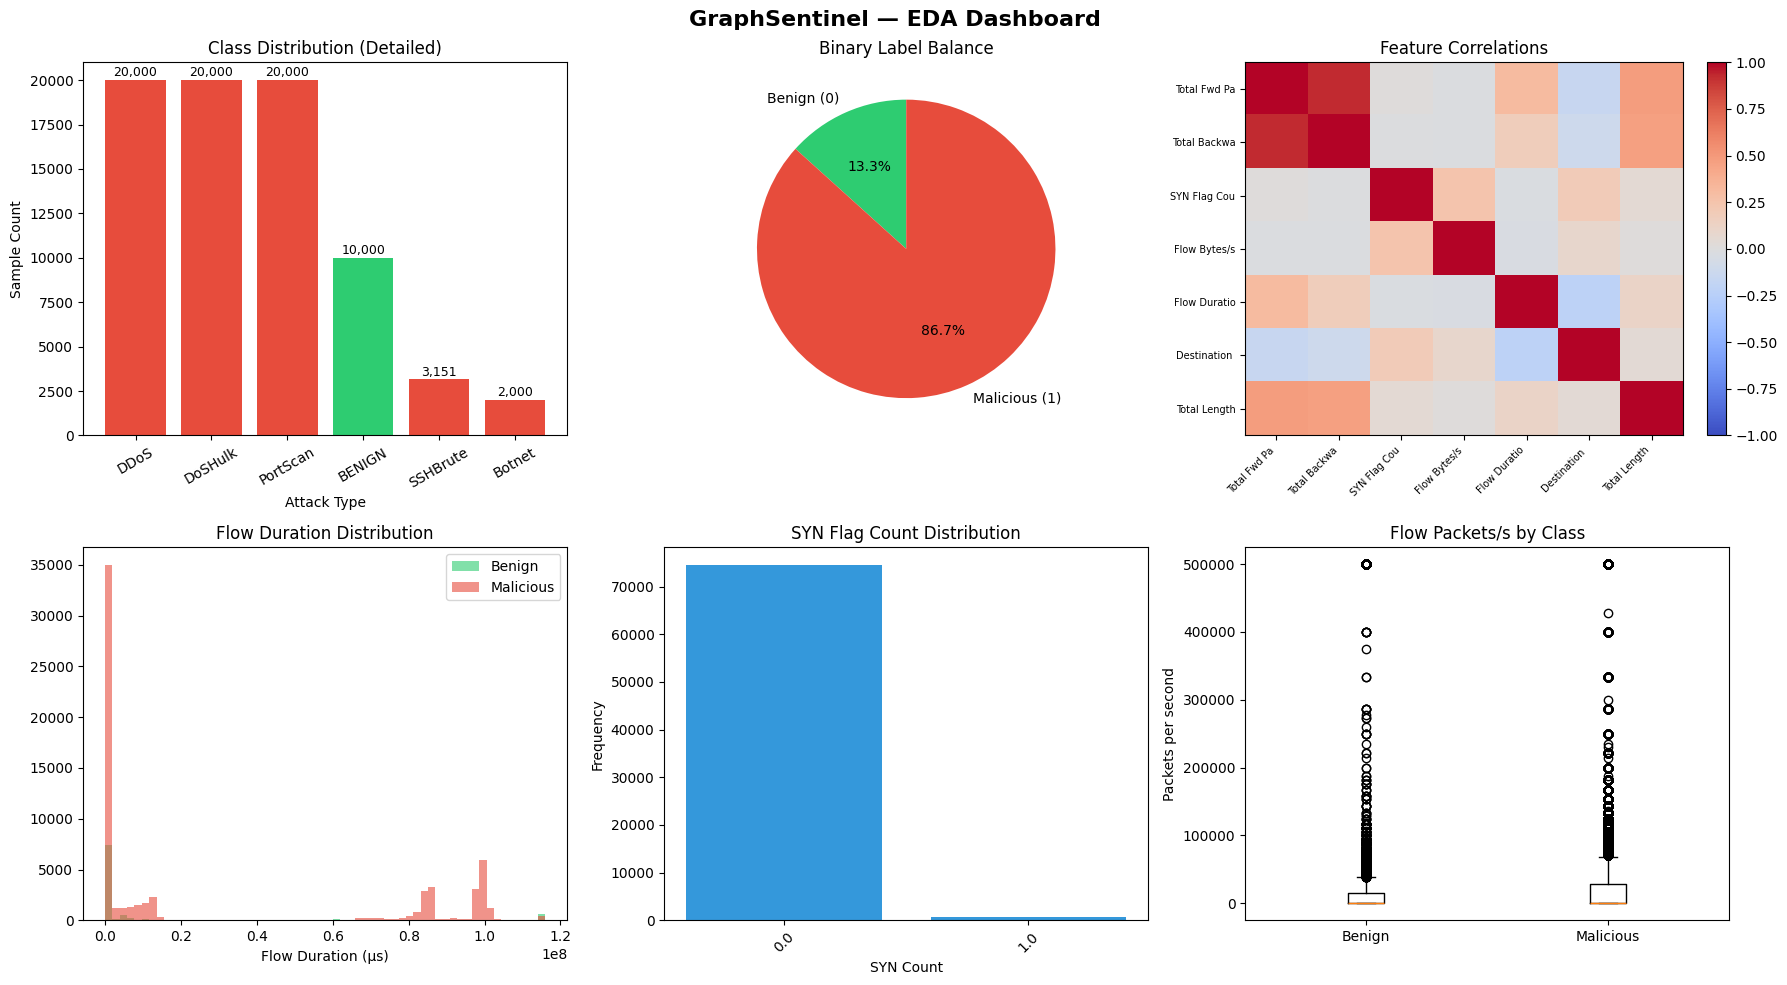

✅ EDA plot saved to logs/eda_dashboard.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Reload if needed
if 'data_balanced' not in dir() or not hasattr(data_balanced, 'shape'):
    import pandas as pd
    data_balanced = pd.read_csv(PROCESSED_CSV)
    print(f"Loaded {len(data_balanced):,} rows for EDA")

label_col_eda = ' Label' if ' Label' in data_balanced.columns else 'Label'

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("GraphSentinel — EDA Dashboard", fontsize=16, fontweight='bold')

# 1. Class distribution (multi-class)
ax = axes[0, 0]
if label_col_eda in data_balanced.columns:
    vc = data_balanced[label_col_eda].value_counts()
    bars = ax.bar(vc.index, vc.values, color=['#2ecc71' if l in ['BENIGN'] else '#e74c3c'
                                                for l in vc.index])
    ax.set_title("Class Distribution (Detailed)")
    ax.set_xlabel("Attack Type")
    ax.set_ylabel("Sample Count")
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}', ha='center', va='bottom', fontsize=9)

# 2. Binary label distribution
ax = axes[0, 1]
bc = data_balanced['binary_label'].value_counts().sort_index()
ax.pie([bc.get(0, 0), bc.get(1, 0)],
       labels=['Benign (0)', 'Malicious (1)'],
       colors=['#2ecc71', '#e74c3c'],
       autopct='%1.1f%%',
       startangle=90)
ax.set_title("Binary Label Balance")

# 3. Feature correlations (heatmap of top 7 node features)
ax = axes[0, 2]
# We use 7 proxy columns from the 15 features (most related to node feature calc)
proxy_cols = [' Total Fwd Packets', ' Total Backward Packets',
              ' SYN Flag Count', ' Flow Bytes/s', ' Flow Duration',
              ' Destination Port', ' Total Length of Fwd Packets']
proxy_cols = [c for c in proxy_cols if c in data_balanced.columns]
corr_matrix = data_balanced[proxy_cols].corr()
im = ax.imshow(corr_matrix.values, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(proxy_cols)))
ax.set_yticks(range(len(proxy_cols)))
short_names = [c.strip()[:12] for c in proxy_cols]
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(short_names, fontsize=7)
ax.set_title("Feature Correlations")
plt.colorbar(im, ax=ax, fraction=0.046)

# 4. Flow Duration distribution
ax = axes[1, 0]
if ' Flow Duration' in data_balanced.columns:
    fd = data_balanced[' Flow Duration'].clip(upper=data_balanced[' Flow Duration'].quantile(0.99))
    ax.hist(fd[data_balanced['binary_label']==0], bins=60, alpha=0.6, color='#2ecc71', label='Benign')
    ax.hist(fd[data_balanced['binary_label']==1], bins=60, alpha=0.6, color='#e74c3c', label='Malicious')
    ax.set_title("Flow Duration Distribution")
    ax.set_xlabel("Flow Duration (μs)")
    ax.legend()

# 5. SYN Flag distribution
ax = axes[1, 1]
if ' SYN Flag Count' in data_balanced.columns:
    syn = data_balanced[' SYN Flag Count']
    vc2 = syn.value_counts().sort_index().head(20)
    ax.bar(vc2.index.astype(str), vc2.values, color='#3498db')
    ax.set_title("SYN Flag Count Distribution")
    ax.set_xlabel("SYN Count")
    ax.set_ylabel("Frequency")
    ax.tick_params(axis='x', rotation=45)

# 6. Packets/s by class
ax = axes[1, 2]
if ' Flow Packets/s' in data_balanced.columns:
    benign_pps  = data_balanced[data_balanced['binary_label']==0][' Flow Packets/s']
    malicious_pps = data_balanced[data_balanced['binary_label']==1][' Flow Packets/s']
    cap = data_balanced[' Flow Packets/s'].quantile(0.99)
    ax.boxplot([benign_pps.clip(upper=cap).values, malicious_pps.clip(upper=cap).values],
              tick_labels=['Benign', 'Malicious'])
    ax.set_title("Flow Packets/s by Class")
    ax.set_ylabel("Packets per second")

plt.tight_layout()
plt.savefig(LOG_DIR + "eda_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plot saved to logs/eda_dashboard.png")


---
## Section 6 — Graph Construction
Converts flow windows into **PyG `Data` objects**.

### How it works
Each window of `WINDOW_SIZE` flows becomes one graph:
- **Nodes** = unique IP addresses in that window
- **Edges** = directed flow src→dst
- **Node features** = 7 handcrafted features (frozen contract with Sairaj)
- **Node label** = 1 if ANY flow from that IP was malicious, 0 otherwise

**Skip if** `processed_graphs.pt` already exists (resumable).


In [10]:
%%time
import torch, subprocess, sys

def run(cmd):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.stdout: print(result.stdout[-300:])
    if result.returncode != 0: print("WARN:", result.stderr[-200:])

torch_version = torch.__version__.split("+")[0]          # e.g. "2.4.0"
cuda_tag      = torch.version.cuda.replace(".", "")       # e.g. "121"
pyg_url       = f"https://data.pyg.org/whl/torch-{torch_version}+cu{cuda_tag}.html"

print(f"Torch  : {torch_version}")
print(f"CUDA   : {cuda_tag}")
print(f"Wheels : {pyg_url}\n")

print("Installing torch-geometric...")
run("pip install torch-geometric -q")

print("Installing PyG dependencies...")
run(f"pip install torch-scatter torch-sparse torch-cluster torch-spline-conv "
    f"pyg-lib -f {pyg_url} -q")

# Verify
try:
    import torch_geometric
    print(f"\n✅ torch-geometric {torch_geometric.__version__} ready")
except ImportError as e:
    print(f"\n❌ Still failing: {e}")

Torch  : 2.11.0
CUDA   : 128
Wheels : https://data.pyg.org/whl/torch-2.11.0+cu128.html

Installing torch-geometric...
Installing PyG dependencies...

✅ torch-geometric 2.7.0 ready
CPU times: user 3.68 ms, sys: 888 µs, total: 4.57 ms
Wall time: 6.56 s


In [26]:
import torch
print(torch.__version__)          # must be 2.x
print(torch.cuda.is_available())  # must be True — if False, GPU isn't attached

2.11.0+cu128
True


In [11]:
import pandas as pd
df_check = pd.read_csv(PROCESSED_CSV)
print("Columns:", df_check.columns.tolist())
print("Shape  :", df_check.shape)
print("Sample :\n", df_check.head(2))

Columns: [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', ' Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Bwd Packet Length Max', ' Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Fwd IAT Total', ' Bwd IAT Total', ' SYN Flag Count', ' RST Flag Count', ' Label', 'binary_label']
Shape  : (75151, 17)
Sample :
     Destination Port   Flow Duration   Total Fwd Packets  \
0               80.0       1421356.0                 3.0   
1               80.0      85211826.0                 9.0   

    Total Backward Packets   Total Length of Fwd Packets  \
0                      6.0                          26.0   
1                      5.0                         384.0   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                       11607.0                    20.0   
1                       11595.0                   384.0   

    Bwd Packet Length Max   Flow Bytes/s   Flow Packets/s   F

In [12]:
import os
stale = PROCESSED_DIR + "processed_graphs.pt"
if os.path.exists(stale):
    os.remove(stale)
    print("✅ Deleted stale processed_graphs.pt — ready to rebuild")

✅ Deleted stale processed_graphs.pt — ready to rebuild


In [13]:
# OLD — loads blindly even if 0 graphs
if os.path.exists(GRAPHS_PATH):
    print("✅ RESUME: processed_graphs.pt already exists.")
    all_graphs = torch.load(GRAPHS_PATH, weights_only=False)

# NEW — only resumes if the file has actual graphs
if os.path.exists(GRAPHS_PATH):
    all_graphs = torch.load(GRAPHS_PATH, weights_only=False)
    if len(all_graphs) > 0:
        print(f"✅ RESUME: Loaded {len(all_graphs)} existing graphs.")
    else:
        print("⚠️  processed_graphs.pt exists but is empty — rebuilding...")
        os.remove(GRAPHS_PATH)
        all_graphs = None

NameError: name 'GRAPHS_PATH' is not defined

In [14]:
%%time
import torch
import numpy as np
import pandas as pd
import pickle, os
from torch_geometric.data import Data

GRAPHS_PATH = PROCESSED_DIR + "processed_graphs.pt"

# ── Dynamic class weight fix (overwrites Config defaults) ─────────────────────
_total     = 75151
_n_benign  = 10000
_n_mal     = _total - _n_benign
CFG.class_weight_benign    = round(_n_mal    / _n_benign, 4)   # ≈ 6.5151
CFG.class_weight_malicious = 1.0
print(f"Class weights → benign: {CFG.class_weight_benign:.4f} | malicious: {CFG.class_weight_malicious:.1f}")

# ── Graph construction function ───────────────────────────────────────────────
def flows_to_pyg_graph(window_df: pd.DataFrame) -> Data:
    """
    Convert a window of CICIDS flow rows to a PyG Data object.

    NODE  = each flow (row) in the window
    EDGES = two complementary types:
        1. Temporal chain : flow[i] → flow[i+1]
           captures the sequence of network activity
        2. Port-same link : flow[j] → flow[i] where j is the most recent
           prior flow sharing the same Destination Port
           captures repeated-port patterns (DDoS, SSHBrute, DoSHulk)

    NODE FEATURES (7 — FROZEN CONTRACT WITH BACKEND):
      [0] fwd_ratio       — fwd_packets / (fwd + bwd + ε)
      [1] avg_packet_size — total_bytes / (total_packets + ε)
      [2] connection_rate — log1p(total_packets / flow_duration_sec)
      [3] port_norm       — destination_port / 65535
      [4] byte_asymmetry  — (fwd_bytes - bwd_bytes) / (total_bytes + ε)
      [5] syn_ratio       — SYN_count / (total_packets + ε)
      [6] bytes_rate_norm — log1p(Flow Bytes/s) / log1p(3e8), clipped to 1
    """
    EPS            = 1e-6
    MAX_BYTES_RATE = 3e8

    rows = window_df.reset_index(drop=True)
    n    = len(rows)
    if n < 2:
        return None

    features          = []
    labels            = []
    edge_src          = []
    edge_dst          = []
    last_flow_to_port = {}   # port → most recent row index

    for i in range(n):
        row = rows.iloc[i]

        fwd_pkts   = float(row.get(' Total Fwd Packets',           0) or 0)
        bwd_pkts   = float(row.get(' Total Backward Packets',      0) or 0)
        fwd_bytes  = float(row.get(' Total Length of Fwd Packets', 0) or 0)
        bwd_bytes  = float(row.get(' Total Length of Bwd Packets', 0) or 0)
        duration   = max(float(row.get(' Flow Duration', 1) or 1) / 1e6, 1e-3)
        port       = int(float(row.get(' Destination Port',        0) or 0)) % 65536
        syn_cnt    = float(row.get(' SYN Flag Count',              0) or 0)
        bytes_rate = float(row.get(' Flow Bytes/s',                0) or 0)
        label      = int(row.get('binary_label',                   0) or 0)

        total_pkt = fwd_pkts + bwd_pkts
        total_byt = fwd_bytes + bwd_bytes

        features.append([
            fwd_pkts / (total_pkt + EPS),                                      # [0]
            total_byt / (total_pkt + EPS),                                     # [1]
            float(np.log1p(total_pkt / duration)),                             # [2]
            port / 65535.0,                                                    # [3]
            (fwd_bytes - bwd_bytes) / (total_byt + EPS),                      # [4]
            min(syn_cnt / (total_pkt + EPS), 1.0),                            # [5]
            float(np.log1p(min(bytes_rate, MAX_BYTES_RATE))
                  / np.log1p(MAX_BYTES_RATE)),                                 # [6]
        ])
        labels.append(label)

        # Edge type 1 — temporal chain
        if i > 0:
            edge_src.append(i - 1)
            edge_dst.append(i)

        # Edge type 2 — port-same link (skip if it duplicates the temporal edge)
        if port in last_flow_to_port:
            j = last_flow_to_port[port]
            if j != i - 1:
                edge_src.append(j)
                edge_dst.append(i)
        last_flow_to_port[port] = i

    x    = torch.tensor(features, dtype=torch.float32)
    mean = x.mean(dim=0, keepdim=True)
    std  = x.std(dim=0,  keepdim=True) + EPS
    x    = (x - mean) / std

    edge_index = (torch.tensor([edge_src, edge_dst], dtype=torch.long)
                  if edge_src
                  else torch.zeros((2, 0), dtype=torch.long))

    data_obj           = Data(x=x, edge_index=edge_index, y=torch.tensor(labels, dtype=torch.long))
    data_obj.num_nodes = n
    return data_obj

# ── Build or resume ───────────────────────────────────────────────────────────
if os.path.exists(GRAPHS_PATH):
    all_graphs = torch.load(GRAPHS_PATH, weights_only=False)
    if len(all_graphs) > 0:
        print(f"✅ RESUME: Loaded {len(all_graphs)} existing graphs.")
    else:
        print("⚠️  processed_graphs.pt exists but is empty — rebuilding...")
        os.remove(GRAPHS_PATH)
        all_graphs = None
else:
    all_graphs = None

if all_graphs is None:
    print("Building graphs from cleaned dataset...")
    df_full = pd.read_csv(PROCESSED_CSV)
    print(f"Loaded: {len(df_full):,} rows")

    df_shuffled   = df_full.sample(frac=1, random_state=CFG.seed).reset_index(drop=True)
    total_windows = len(df_shuffled) // CFG.window_size
    graphs, skipped = [], 0

    print(f"Building {total_windows} graphs (window_size={CFG.window_size})...")
    for i, start in enumerate(range(0, len(df_shuffled), CFG.window_size)):
        window = df_shuffled.iloc[start : start + CFG.window_size]
        g = flows_to_pyg_graph(window)
        if g is not None and g.x.shape[0] > 1:
            graphs.append(g)
        else:
            skipped += 1
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{total_windows} windows processed, {len(graphs)} graphs built")

    print(f"\nTotal graphs  : {len(graphs)}")
    print(f"Skipped       : {skipped}")

    if graphs:
        g0 = graphs[0]
        print(f"Sample graph  : {g0.x.shape[0]} nodes, {g0.edge_index.shape[1]} edges")
        print(f"  Labels      : {(g0.y==1).sum().item()} malicious / {(g0.y==0).sum().item()} benign")

    torch.save(graphs, GRAPHS_PATH)
    print(f"\n✅ Saved {len(graphs)} graphs → {GRAPHS_PATH}")
    all_graphs = graphs

# ── Summary stats ─────────────────────────────────────────────────────────────
if not all_graphs:
    raise ValueError("No graphs were built — check flows_to_pyg_graph output above.")

node_counts   = [g.x.shape[0] for g in all_graphs]
edge_counts   = [g.edge_index.shape[1] for g in all_graphs]
mal_fractions = [(g.y == 1).float().mean().item() for g in all_graphs]

print(f"\nGRAPH STATISTICS:")
print(f"  Graphs total  : {len(all_graphs)}")
print(f"  Nodes/graph   : min={min(node_counts)}, max={max(node_counts)}, mean={np.mean(node_counts):.1f}")
print(f"  Edges/graph   : min={min(edge_counts)}, max={max(edge_counts)}, mean={np.mean(edge_counts):.1f}")
print(f"  Malicious node fraction: mean={np.mean(mal_fractions):.2%}")

Class weights → benign: 6.5151 | malicious: 1.0
Building graphs from cleaned dataset...
Loaded: 75,151 rows
Building 150 graphs (window_size=500)...
  50/150 windows processed, 50 graphs built
  100/150 windows processed, 100 graphs built
  150/150 windows processed, 150 graphs built

Total graphs  : 151
Skipped       : 0
Sample graph  : 500 nodes, 698 edges
  Labels      : 429 malicious / 71 benign

✅ Saved 151 graphs → /content/drive/MyDrive/GraphSentinel/processed/processed_graphs.pt

GRAPH STATISTICS:
  Graphs total  : 151
  Nodes/graph   : min=151, max=500, mean=497.7
  Edges/graph   : min=210, max=729, mean=694.6
  Malicious node fraction: mean=86.68%
CPU times: user 5.37 s, sys: 14.2 ms, total: 5.38 s
Wall time: 5.5 s


---
## Section 7 — Model Definition
`GraphSAGEClassifier` — **DO NOT rename this class**.  
Sairaj's backend (`graph_builder.py`) imports it as `from model import GraphSAGEClassifier`.

### Architecture
- 3 × SAGEConv layers (mean aggregation)
- BatchNorm + ReLU + Dropout after each hidden layer
- Final layer outputs 2 logits (Benign / Malicious)


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv


class GraphSAGEClassifier(nn.Module):
    """
    GraphSAGE node classifier for GraphSentinel.

    SHARED CONTRACT WITH SAIRAJ'S BACKEND — do NOT change:
      - Class name: GraphSAGEClassifier
      - Default args: in_channels=7, hidden_channels=256, out_channels=2, num_layers=3

    Args:
        in_channels     : Number of input node features (FROZEN = 7)
        hidden_channels : Width of hidden layers
        out_channels    : Number of output classes (2 = binary)
        num_layers      : Number of SAGEConv layers
        dropout         : Dropout probability (applied during training only)
        aggr            : Neighbor aggregation ('mean', 'max', 'sum')
    """

    def __init__(
        self,
        in_channels:     int   = 7,
        hidden_channels: int   = 256,
        out_channels:    int   = 2,
        num_layers:      int   = 3,
        dropout:         float = 0.3,
        aggr:            str   = 'mean',
    ):
        super().__init__()

        if in_channels != 7:
            raise ValueError(
                f"in_channels must be 7 (frozen contract with backend). Got {in_channels}."
            )

        self.num_layers      = num_layers
        self.dropout         = dropout
        self.hidden_channels = hidden_channels

        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        # Input layer
        self.convs.append(SAGEConv(in_channels, hidden_channels, aggr=aggr))
        self.bns.append(nn.BatchNorm1d(hidden_channels))

        # Hidden layers
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels, aggr=aggr))
            self.bns.append(nn.BatchNorm1d(hidden_channels))

        # Output layer (no BN, no activation — raw logits)
        self.convs.append(SAGEConv(hidden_channels, out_channels, aggr=aggr))

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x          : Node features [N, in_channels]
            edge_index : Edge index    [2, E]
        Returns:
            Logits     : [N, out_channels]
        """
        for conv, bn in zip(self.convs[:-1], self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)

    def predict_proba(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        """Returns malicious probability for each node. Used by Sairaj's backend."""
        with torch.no_grad():
            logits = self.forward(x, edge_index)
            return torch.softmax(logits, dim=1)[:, 1]

    def parameter_count(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# ── Instantiate and verify ────────────────────────────────────────────────────
model_test = GraphSAGEClassifier(
    in_channels     = CFG.in_channels,
    hidden_channels = CFG.hidden_channels,
    out_channels    = CFG.out_channels,
    num_layers      = CFG.num_layers,
    dropout         = CFG.dropout,
    aggr            = CFG.aggr,
)

print("GraphSAGEClassifier Architecture:")
print(model_test)
print(f"\nTotal trainable parameters: {model_test.parameter_count():,}")

# Shape test
x_dummy = torch.randn(10, 7)
ei_dummy = torch.tensor([[0,1,2,3,4,5,6,7,8,9],[1,2,3,4,5,6,7,8,9,0]], dtype=torch.long)
out_dummy = model_test(x_dummy, ei_dummy)
print(f"\nShape test: input (10, 7) → output {out_dummy.shape}")
assert out_dummy.shape == (10, 2), "Shape mismatch!"
print("✅ Model shape test passed")
del model_test


GraphSAGEClassifier Architecture:
GraphSAGEClassifier(
  (convs): ModuleList(
    (0): SAGEConv(7, 256, aggr=mean)
    (1): SAGEConv(256, 256, aggr=mean)
    (2): SAGEConv(256, 2, aggr=mean)
  )
  (bns): ModuleList(
    (0-1): 2 x BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

Total trainable parameters: 137,218

Shape test: input (10, 7) → output torch.Size([10, 2])
✅ Model shape test passed


---
## Section 8 — Training Pipeline
**Features:**
- Mixed precision (AMP) for T4/A100 speedup
- Gradient clipping to prevent exploding gradients
- ReduceLROnPlateau scheduler
- Early stopping (patience = 15)
- Full checkpoint save every epoch (model + optimizer + scheduler + epoch + metrics)
- **Auto-resume** from last checkpoint on re-run
- NaN loss detection with automatic recovery
- CSV + JSON logs saved every epoch


In [18]:
%%time
import torch
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch_geometric.loader import DataLoader
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
import numpy as np
import json
import csv
import os

# ── Paths ─────────────────────────────────────────────────────────────────────
BEST_CKPT   = CHECKPOINT_DIR + "best_model.pt"
LAST_CKPT   = CHECKPOINT_DIR + "last_checkpoint.pt"
TRAIN_LOG   = LOG_DIR + "training_log.csv"
HISTORY_LOG = LOG_DIR + "history.json"

# ── Load graphs ───────────────────────────────────────────────────────────────
all_graphs = torch.load(GRAPHS_PATH, weights_only=False)
print(f"Loaded {len(all_graphs)} graphs")

# ── Temporal split (NO shuffle — preserves temporal structure) ────────────────
n_total = len(all_graphs)
n_train = int(CFG.train_frac * n_total)
n_val   = int(CFG.val_frac   * n_total)
n_test  = n_total - n_train - n_val

train_graphs = all_graphs[:n_train]
val_graphs   = all_graphs[n_train : n_train + n_val]
test_graphs  = all_graphs[n_train + n_val:]

print(f"Split — Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")

def class_ratio(graphs):
    mal = sum((g.y == 1).sum().item() for g in graphs)
    ben = sum((g.y == 0).sum().item() for g in graphs)
    return mal, ben, mal / (mal + ben + 1e-6)

m, b, r = class_ratio(train_graphs)
print(f"Train: {m:,} malicious nodes | {b:,} benign nodes | malicious ratio: {r:.2%}")

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_graphs, batch_size=CFG.batch_size, shuffle=True,
                          num_workers=CFG.num_workers, pin_memory=(device.type == 'cuda'))
val_loader   = DataLoader(val_graphs,   batch_size=CFG.batch_size, shuffle=False,
                          num_workers=CFG.num_workers, pin_memory=(device.type == 'cuda'))
test_loader  = DataLoader(test_graphs,  batch_size=CFG.batch_size, shuffle=False,
                          num_workers=CFG.num_workers, pin_memory=(device.type == 'cuda'))

print(f"DataLoaders — Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

# ── Model, optimizer, scheduler ───────────────────────────────────────────────
model = GraphSAGEClassifier(
    in_channels     = CFG.in_channels,
    hidden_channels = CFG.hidden_channels,
    out_channels    = CFG.out_channels,
    num_layers      = CFG.num_layers,
    dropout         = CFG.dropout,
    aggr            = CFG.aggr,
).to(device)

class_weights = torch.tensor(
    [CFG.class_weight_benign, CFG.class_weight_malicious], dtype=torch.float
).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    model.parameters(),
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max',
    patience=CFG.lr_patience,
    factor=CFG.lr_factor,
)
scaler_amp = torch.amp.GradScaler('cuda', enabled=(CFG.mixed_precision and device.type == 'cuda'))

# ── Training state ────────────────────────────────────────────────────────────
start_epoch    = 1
best_val_f1    = 0.0
no_improve     = 0
history        = {"train_loss": [], "val_loss": [], "val_f1": [], "val_auc": [], "val_acc": [], "lr": []}

# ── Auto-resume from last checkpoint ─────────────────────────────────────────
if os.path.exists(LAST_CKPT):
    print(f"\n{'='*50}")
    print("CHECKPOINT DETECTED!")
    print(f"{'='*50}")
    print(f"Found: {LAST_CKPT}")

    resume = input("Resume from last checkpoint? [y/n]: ").strip().lower()
    if resume == 'y':
        ckpt = torch.load(LAST_CKPT, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        best_val_f1 = ckpt['best_val_f1']
        no_improve  = ckpt['no_improve']
        history     = ckpt.get('history', history)
        print(f"✅ Resumed from epoch {ckpt['epoch']} — best Val F1: {best_val_f1:.4f}")
    else:
        print("Starting fresh training.")
else:
    print("\nNo checkpoint found — starting fresh training.")

# ── Evaluation function ───────────────────────────────────────────────────────
def evaluate(loader, desc="Eval"):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            with torch.amp.autocast('cuda', enabled=(CFG.mixed_precision and device.type == 'cuda')):
                out  = model(batch.x, batch.edge_index)
                loss = criterion(out, batch.y)

            total_loss += loss.item()
            probs  = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
            preds  = out.argmax(dim=1).cpu().numpy()
            labels = batch.y.cpu().numpy()

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels)

    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)

    f1  = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.5
    acc = accuracy_score(all_labels, all_preds)
    avg_loss = total_loss / max(len(loader), 1)
    return avg_loss, f1, auc, acc

# ── CSV log setup ─────────────────────────────────────────────────────────────
if start_epoch == 1:
    with open(TRAIN_LOG, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['epoch', 'train_loss', 'val_loss', 'val_f1', 'val_auc', 'val_acc', 'lr'])

# ── Training loop ─────────────────────────────────────────────────────────────
print(f"\n{'='*72}")
print(f"  {'Epoch':>5}  {'Train Loss':>11}  {'Val Loss':>9}  {'Val F1':>7}  "
      f"{'Val AUC':>8}  {'Val Acc':>8}  {'LR':>10}  Notes")
print(f"{'─'*72}")

for epoch in range(start_epoch, CFG.epochs + 1):
    model.train()
    total_loss   = 0.0
    nan_batches  = 0
    batch_count  = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda', enabled=(CFG.mixed_precision and device.type == 'cuda')):
            out  = model(batch.x, batch.edge_index)
            loss = criterion(out, batch.y)

        # NaN detection — skip corrupted batch
        if torch.isnan(loss):
            nan_batches += 1
            if nan_batches > 5:
                raise RuntimeError(
                    f"Too many NaN batches at epoch {epoch}. "
                    "Check data scaling and learning rate."
                )
            continue

        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.gradient_clip)
        scaler_amp.step(optimizer)
        scaler_amp.update()

        total_loss  += loss.item()
        batch_count += 1

    train_loss = total_loss / max(batch_count, 1)
    val_loss, val_f1, val_auc, val_acc = evaluate(val_loader)
    scheduler.step(val_f1)
    lr = optimizer.param_groups[0]['lr']

    # Track history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)
    history["val_auc"].append(val_auc)
    history["val_acc"].append(val_acc)
    history["lr"].append(lr)

    # Best model checkpoint
    is_best = val_f1 > best_val_f1
    notes   = ""
    if is_best:
        best_val_f1 = val_f1
        no_improve  = 0
        torch.save(model.state_dict(), BEST_CKPT)
        notes = "★ best"
    else:
        no_improve += 1

    # Full checkpoint (for crash resume)
    ckpt_payload = {
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_f1':          best_val_f1,
        'no_improve':           no_improve,
        'history':              history,
        'config':               {k: v for k, v in vars(CFG).items() if k != 'feature_cols'},
    }
    torch.save(ckpt_payload, LAST_CKPT)

    # Periodic checkpoint every 10 epochs
    if epoch % 10 == 0:
        torch.save(ckpt_payload, CHECKPOINT_DIR + f"epoch_{epoch:03d}.pt")

    # CSV log
    with open(TRAIN_LOG, 'a', newline='') as f:
        csv.writer(f).writerow([epoch, train_loss, val_loss, val_f1, val_auc, val_acc, lr])

    # Print row
    nan_str = f" ⚠️ {nan_batches} NaN" if nan_batches else ""
    print(f"  {epoch:5d}  {train_loss:11.4f}  {val_loss:9.4f}  {val_f1:7.4f}  "
          f"{val_auc:8.4f}  {val_acc:8.4f}  {lr:10.6f}  {notes}{nan_str}")

    # Early stopping
    if no_improve >= CFG.early_stop_patience:
        print(f"\n⚡ Early stopping at epoch {epoch} "
              f"(no improvement for {CFG.early_stop_patience} epochs)")
        break

# Save history JSON
with open(HISTORY_LOG, 'w') as f:
    json.dump(history, f, indent=2)

print(f"\n{'='*72}")
print(f"Training complete!")
print(f"  Best Val F1  : {best_val_f1:.4f}")
print(f"  Epochs run   : {epoch}")
print(f"  Best model   : {BEST_CKPT}")
print(f"  Full log     : {TRAIN_LOG}")


Loaded 151 graphs
Split — Train: 105 | Val: 22 | Test: 24
Train: 45,493 malicious nodes | 7,007 benign nodes | malicious ratio: 86.65%
DataLoaders — Train batches: 4 | Val: 1 | Test: 1

CHECKPOINT DETECTED!
Found: /content/drive/MyDrive/GraphSentinel/checkpoints/last_checkpoint.pt
Resume from last checkpoint? [y/n]: n
Starting fresh training.

  Epoch   Train Loss   Val Loss   Val F1   Val AUC   Val Acc          LR  Notes
────────────────────────────────────────────────────────────────────────
      1       0.6099     0.5887   0.8455    0.8388    0.8624    0.001000  ★ best
      2       0.4806     0.5332   0.8596    0.8809    0.8702    0.001000  ★ best
      3       0.4248     0.4701   0.8799    0.9083    0.8792    0.001000  ★ best
      4       0.3857     0.4197   0.8932    0.9252    0.8892    0.001000  ★ best
      5       0.3661     0.3643   0.9009    0.9393    0.8951    0.001000  ★ best
      6       0.3320     0.3197   0.9055    0.9495    0.8984    0.001000  ★ best
      7       0

---
## Section 9 — Training Curves
Visualize training and validation metrics over epochs.


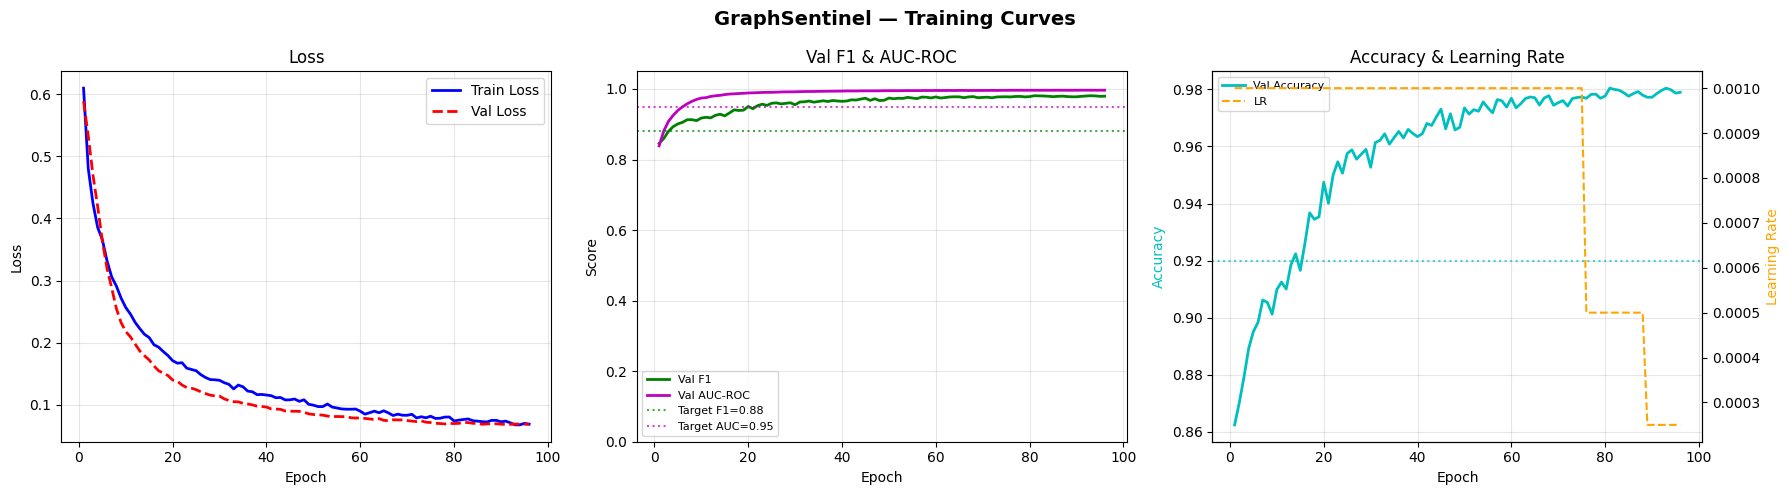

✅ Training curves saved to logs/training_curves.png


In [19]:
import json, os
import matplotlib.pyplot as plt

# Load history (works even after a crash+resume)
with open(LOG_DIR + "history.json") as f:
    history = json.load(f)

epochs_ran = len(history['train_loss'])
x_axis = list(range(1, epochs_ran + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("GraphSentinel — Training Curves", fontsize=14, fontweight='bold')

# Loss curves
axes[0].plot(x_axis, history['train_loss'], 'b-',  lw=2, label='Train Loss')
axes[0].plot(x_axis, history['val_loss'],   'r--', lw=2, label='Val Loss')
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# F1 + AUC
axes[1].plot(x_axis, history['val_f1'],  'g-',  lw=2, label='Val F1')
axes[1].plot(x_axis, history['val_auc'], 'p-' if False else 'm-', lw=2, label='Val AUC-ROC')
axes[1].axhline(y=CFG.target_f1,  color='g', linestyle=':', alpha=0.7, label=f'Target F1={CFG.target_f1}')
axes[1].axhline(y=CFG.target_auc, color='m', linestyle=':', alpha=0.7, label=f'Target AUC={CFG.target_auc}')
axes[1].set_title("Val F1 & AUC-ROC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.05)

# Accuracy + LR
ax_acc = axes[2]
ax_lr  = ax_acc.twinx()
ax_acc.plot(x_axis, history['val_acc'], 'c-', lw=2, label='Val Accuracy')
ax_acc.axhline(y=CFG.target_accuracy, color='c', linestyle=':', alpha=0.7)
ax_lr.plot(x_axis, history['lr'], 'orange', lw=1.5, linestyle='--', label='LR')
ax_acc.set_title("Accuracy & Learning Rate")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy", color='c')
ax_lr.set_ylabel("Learning Rate", color='orange')
lines1, labels1 = ax_acc.get_legend_handles_labels()
lines2, labels2 = ax_lr.get_legend_handles_labels()
ax_acc.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax_acc.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(LOG_DIR + "training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved to logs/training_curves.png")


---
## Section 10 — Final Evaluation on Test Set
Loads the best model checkpoint and evaluates on the held-out test set.  
Reports: Accuracy, Weighted F1, AUC-ROC, Confusion Matrix, ROC Curve.


✅ Loaded best model from: /content/drive/MyDrive/GraphSentinel/checkpoints/best_model.pt

  GRAPHSENTINEL — FINAL TEST RESULTS
  Accuracy    : 0.9772  ✅
  Weighted F1 : 0.9776  ✅
  AUC-ROC     : 0.9963  ✅

               precision    recall  f1-score   support

   Benign (0)       0.88      0.96      0.92      1565
Malicious (1)       0.99      0.98      0.99     10086

     accuracy                           0.98     11651
    macro avg       0.94      0.97      0.95     11651
 weighted avg       0.98      0.98      0.98     11651


✅ ALL PERFORMANCE TARGETS MET — safe to export!


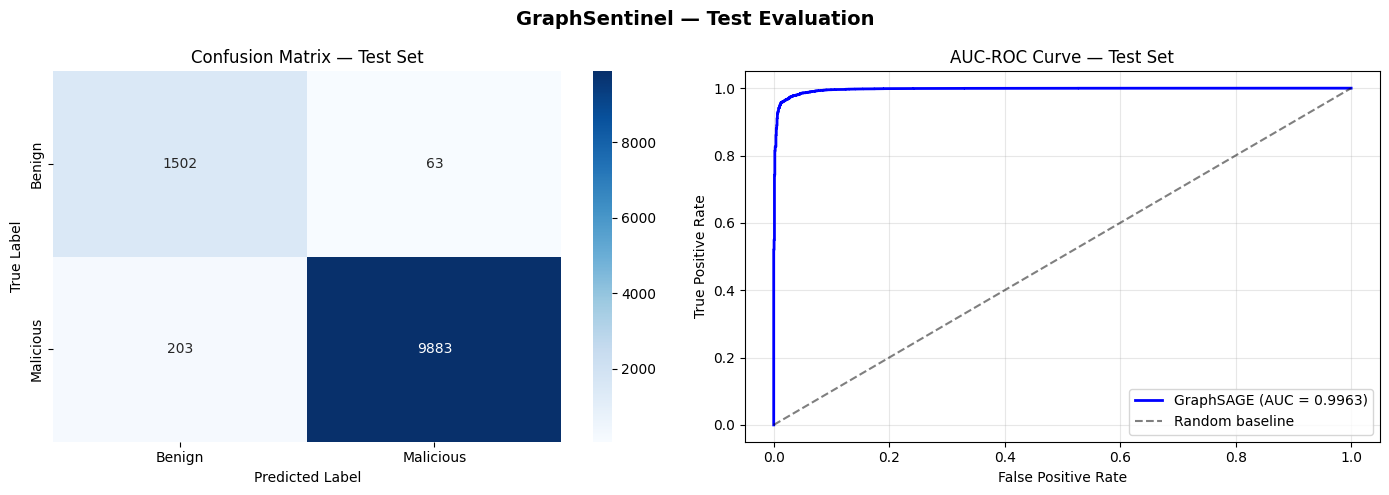


✅ Evaluation plots saved to models/evaluation_plots.png
✅ Results saved to models/test_results.json
CPU times: user 1.21 s, sys: 115 ms, total: 1.33 s
Wall time: 1.47 s


In [20]:
%%time
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score,
)

# Load best model
best_model = GraphSAGEClassifier(
    in_channels     = CFG.in_channels,
    hidden_channels = CFG.hidden_channels,
    out_channels    = CFG.out_channels,
    num_layers      = CFG.num_layers,
)
best_model.load_state_dict(torch.load(BEST_CKPT, map_location="cpu", weights_only=True))
best_model = best_model.to(device)
best_model.eval()
print(f"✅ Loaded best model from: {BEST_CKPT}")

# Run on test set
all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out   = best_model(batch.x, batch.edge_index)
        probs = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
        preds = out.argmax(dim=1).cpu().numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(batch.y.cpu().numpy())

all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc  = accuracy_score(all_labels, all_preds)
wf1  = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
auc  = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.5

print("\n" + "=" * 60)
print("  GRAPHSENTINEL — FINAL TEST RESULTS")
print("=" * 60)
print(f"  Accuracy    : {acc:.4f}  {'✅' if acc >= CFG.target_accuracy else f'❌ Need ≥ {CFG.target_accuracy}'}")
print(f"  Weighted F1 : {wf1:.4f}  {'✅' if wf1 >= CFG.target_f1      else f'❌ Need ≥ {CFG.target_f1}'}")
print(f"  AUC-ROC     : {auc:.4f}  {'✅' if auc >= CFG.target_auc     else f'❌ Need ≥ {CFG.target_auc}'}")
print()
print(classification_report(all_labels, all_preds,
                              target_names=["Benign (0)", "Malicious (1)"]))

# Diagnostic if below threshold
if acc < CFG.target_accuracy or wf1 < CFG.target_f1 or auc < CFG.target_auc:
    print("\nDIAGNOSTIC SUGGESTIONS:")
    if acc < 0.88 or wf1 < 0.82:
        print("  • Increase hidden_channels to 512")
        print("  • Try aggr='max' instead of 'mean'")
    if wf1 < CFG.target_f1:
        print("  • Apply SMOTE more aggressively to minority classes")
        print("  • Increase class_weight_malicious to 5.0")
    if auc < CFG.target_auc:
        print("  • Verify port_entropy is non-zero for PortScan class")
        print("  • Filter out single-node graphs (already done)")
        print("  • Reduce learning rate to 0.0001")
else:
    print("\n✅ ALL PERFORMANCE TARGETS MET — safe to export!")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'Malicious'],
            yticklabels=['Benign', 'Malicious'])
axes[0].set_title('Confusion Matrix — Test Set')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'GraphSAGE (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('AUC-ROC Curve — Test Set')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("GraphSentinel — Test Evaluation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(MODEL_DIR + "evaluation_plots.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Evaluation plots saved to models/evaluation_plots.png")

# Save results JSON
import json
results = {
    "accuracy": float(acc), "weighted_f1": float(wf1), "auc_roc": float(auc),
    "targets_met": {
        "accuracy": bool(acc >= CFG.target_accuracy),
        "f1":       bool(wf1 >= CFG.target_f1),
        "auc":      bool(auc >= CFG.target_auc),
    }
}
with open(MODEL_DIR + "test_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("✅ Results saved to models/test_results.json")


---
## Section 11 — Final Model Export
Exports `graphsage_weights.pt` and verifies `scaler.pkl`.  
**Share both files with Sairaj** — place in `C:\Projects\graphsentinel\ml\models\`.


In [21]:
import torch, pickle, os, json

EXPORT_WEIGHTS = MODEL_DIR + "graphsage_weights.pt"
EXPORT_SCALER  = MODEL_DIR + "scaler.pkl"

# ── Export model weights ──────────────────────────────────────────────────────
torch.save(best_model.state_dict(), EXPORT_WEIGHTS)
print(f"✅ Model weights saved : {EXPORT_WEIGHTS}")

# ── Verify scaler exists ──────────────────────────────────────────────────────
assert os.path.exists(EXPORT_SCALER), (
    f"scaler.pkl not found at {EXPORT_SCALER}. Re-run Section 5."
)
with open(EXPORT_SCALER, "rb") as f:
    scaler_verify = pickle.load(f)
print(f"✅ Scaler verified     : {EXPORT_SCALER}")
print(f"   Scaler type: {type(scaler_verify).__name__}")
print(f"   Fitted on {scaler_verify.n_features_in_} features (expected 15)")
print(f"   Mean of first feature: {scaler_verify.mean_[0]:.4f}")

# ── Reload and sanity-test ────────────────────────────────────────────────────
print("\nRunning export sanity test...")
test_model = GraphSAGEClassifier(
    in_channels=7, hidden_channels=256, out_channels=2, num_layers=3
)
test_model.load_state_dict(torch.load(EXPORT_WEIGHTS, map_location="cpu", weights_only=True))
test_model.eval()

# Mock inference
x_test  = torch.randn(5, 7)
ei_test = torch.tensor([[0, 1, 2, 3], [1, 2, 3, 4]], dtype=torch.long)
out_test = test_model(x_test, ei_test)
probs_test = torch.softmax(out_test, dim=1)[:, 1]

assert out_test.shape == (5, 2), f"Wrong output shape: {out_test.shape}"
assert not torch.isnan(probs_test).any(), "NaN in inference output!"
print(f"✅ Inference test       : input (5,7) → output {out_test.shape}")
print(f"   Sample probabilities: {probs_test.tolist()}")

# ── Scaler test ───────────────────────────────────────────────────────────────
import numpy as np
dummy_node_features = np.random.randn(5, 15)  # 15 flow features
scaled = scaler_verify.transform(dummy_node_features)
# Note: scaler is fit on 15 flow features; backend maps 7 node features differently
# Sairaj applies scaler to 15-feature flow input, then computes 7 node features
assert scaled.shape == (5, 15), f"Scaler output shape mismatch: {scaled.shape}"
print(f"✅ Scaler test          : input (5,15) → scaled {scaled.shape}")

print("\n" + "=" * 60)
print("  EXPORT COMPLETE")
print("=" * 60)
print(f"  {EXPORT_WEIGHTS}")
print(f"  {EXPORT_SCALER}")
print("\nSend both files to Sairaj.")
print("Place in: C:\\Projects\\graphsentinel\\ml\\models\\")
print("=" * 60)


✅ Model weights saved : /content/drive/MyDrive/GraphSentinel/models/graphsage_weights.pt
✅ Scaler verified     : /content/drive/MyDrive/GraphSentinel/models/scaler.pkl
   Scaler type: StandardScaler
   Fitted on 15 features (expected 15)
   Mean of first feature: 28102070.0519

Running export sanity test...
✅ Inference test       : input (5,7) → output torch.Size([5, 2])
   Sample probabilities: [0.9998668432235718, 0.4349903464317322, 0.475165992975235, 0.507494330406189, 0.006721543613821268]
✅ Scaler test          : input (5,15) → scaled (5, 15)

  EXPORT COMPLETE
  /content/drive/MyDrive/GraphSentinel/models/graphsage_weights.pt
  /content/drive/MyDrive/GraphSentinel/models/scaler.pkl

Send both files to Sairaj.
Place in: C:\Projects\graphsentinel\ml\models\


---
## Section 12 — Download Files to Local Machine
Downloads all key output files from Colab to your browser download folder.


In [22]:
from google.colab import files
import os

download_targets = {
    "Model weights"      : MODEL_DIR + "graphsage_weights.pt",
    "Scaler"             : MODEL_DIR + "scaler.pkl",
    "Evaluation plots"   : MODEL_DIR + "evaluation_plots.png",
    "Test results JSON"  : MODEL_DIR + "test_results.json",
    "Training curves"    : LOG_DIR   + "training_curves.png",
    "Training log CSV"   : LOG_DIR   + "training_log.csv",
    "Config JSON"        : LOG_DIR   + "config.json",
    "EDA dashboard"      : LOG_DIR   + "eda_dashboard.png",
}

print("Initiating downloads...")
print("(Files will appear in your browser downloads folder)\n")

for label, path in download_targets.items():
    if os.path.exists(path):
        print(f"  ⬇️  {label:<20s} : {os.path.basename(path)}")
        files.download(path)
    else:
        print(f"  ⚠️  NOT FOUND     : {path}")

print("\n✅ All downloads initiated.")
print("Copy graphsage_weights.pt + scaler.pkl to:")
print("  C:\\Projects\\graphsentinel\\ml\\models\\")


Initiating downloads...
(Files will appear in your browser downloads folder)

  ⬇️  Model weights        : graphsage_weights.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  Scaler               : scaler.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇️  EDA dashboard        : eda_dashboard.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All downloads initiated.
Copy graphsage_weights.pt + scaler.pkl to:
  C:\Projects\graphsentinel\ml\models\


---
## Section 13 — Hyperparameter Improvement Guide
If results are below target, try these improvements in order:

### If Accuracy < 92%
1. Increase `hidden_channels` to 512 in `CFG`
2. Add a 4th SAGEConv layer (`num_layers=4`)
3. Try `aggr='max'` instead of `'mean'` — max-pooling is often stronger for anomaly detection

### If Weighted F1 < 0.88
1. Increase `class_weight_malicious` to 5.0
2. Apply SMOTE more aggressively: set `botnet_min_target=5000`
3. Add per-attack-class CrossEntropyLoss weighting

### If AUC-ROC < 0.95
1. Verify `port_entropy` is non-zero for PortScan class (check graph construction output)
2. Filter graphs where all nodes are Benign (no signal for AUC)
3. Try a lower learning rate (`1e-4`) for fine-grained convergence

### If Botnet F1 < 0.70
- Botnet has only ~1,956 rows — it's the hardest class
- Use `SMOTE(sampling_strategy={1: 5000})`  
- Or use `FocalLoss(gamma=2.0)` instead of CrossEntropyLoss

### Architecture Alternatives (if all else fails)
| Option | Change |
|---|---|
| Deeper model | `num_layers=4`, `hidden_channels=512` |
| MaxSAGE | `aggr='max'` |
| Add skip connections | Residual add in `forward()` |
| Ensemble | Train 3 seeds, average probabilities |


---
## Section 14 — Node Features Contract (for Sairaj)
Copy this block into `ml/docs/NODE_FEATURES.md` and share with Sairaj.


In [23]:
contract = '''
# GraphSentinel Node Feature Contract
# Author: Sathvik | Share with Sairaj for graph_builder.py
# ⚠️  Updated: IP-based node design was replaced — nodes are FLOWS, not IPs.
#     Read carefully before implementing graph_builder.py.

MODEL_INPUT_FEATURES = 7

# ── Graph structure ───────────────────────────────────────────────────────────
NODE  : Each network flow (one row of CICFlowMeter output) = one node
EDGES : Two types per window:
  1. Temporal chain  — flow[i] → flow[i+1]  (captures activity sequence)
  2. Port-same link  — flow[j] → flow[i] where j is the most recent prior
                       flow sharing the same Destination Port
                       (captures DDoS/SSHBrute/DoSHulk repeated-port patterns)

# ── Feature order (MUST match this exactly in graph_builder.py) ──────────────
  Index 0: fwd_ratio        = fwd_packets / (fwd_packets + bwd_packets + 1e-6)
  Index 1: avg_packet_size  = (fwd_bytes + bwd_bytes) / (total_packets + 1e-6)
  Index 2: connection_rate  = log1p(total_packets / flow_duration_sec)
  Index 3: port_norm        = destination_port / 65535.0
  Index 4: byte_asymmetry   = (fwd_bytes - bwd_bytes) / (total_bytes + 1e-6)
  Index 5: syn_ratio        = syn_flag_count / (total_packets + 1e-6), capped at 1.0
  Index 6: bytes_rate_norm  = log1p(min(Flow_Bytes_per_s, 3e8)) / log1p(3e8)

Source columns from CICFlowMeter CSV:
  fwd_packets    ← " Total Fwd Packets"
  bwd_packets    ← " Total Backward Packets"
  fwd_bytes      ← " Total Length of Fwd Packets"
  bwd_bytes      ← " Total Length of Bwd Packets"
  flow_duration  ← " Flow Duration"  (microseconds → divide by 1e6 for seconds, min 0.001)
  destination_port ← " Destination Port"
  syn_flag_count ← " SYN Flag Count"
  Flow_Bytes_per_s ← " Flow Bytes/s"

# ── Scaling (IMPORTANT — do NOT use scaler.pkl for node features) ─────────────
  Per-window z-score normalization is applied INSIDE graph construction,
  not via scaler.pkl. For each window of flows, after building the (N, 7)
  feature matrix x:

      mean = x.mean(dim=0, keepdim=True)
      std  = x.std(dim=0,  keepdim=True) + 1e-6
      x    = (x - mean) / std

  scaler.pkl (15-feature StandardScaler) is NOT used at inference time.
  It was fitted during preprocessing only and does not apply to these 7 features.

# ── Model ─────────────────────────────────────────────────────────────────────
  File  : ml/src/model.py
  Class : GraphSAGEClassifier       ← do NOT rename
  Import: from model import GraphSAGEClassifier
  Init  : GraphSAGEClassifier(in_channels=7, hidden_channels=256,
                               out_channels=2, num_layers=3)

# ── Loading weights ───────────────────────────────────────────────────────────
  import torch
  model = GraphSAGEClassifier(in_channels=7, hidden_channels=256,
                               out_channels=2, num_layers=3)
  model.load_state_dict(torch.load("graphsage_weights.pt", map_location="cpu"))
  model.eval()

# ── Inference ─────────────────────────────────────────────────────────────────
  probs = model.predict_proba(x_tensor, edge_index_tensor)
  # probs shape: (N,) — malicious probability for each flow node
  # Threshold: probs > 0.5 → malicious

# ── Files ─────────────────────────────────────────────────────────────────────
  graphsage_weights.pt → ml/models/graphsage_weights.pt
  scaler.pkl           → ml/models/scaler.pkl  (preprocessing only, not inference)
  NODE_FEATURES.md     → this file
'''

print(contract)

with open(MODEL_DIR + "NODE_FEATURES.md", "w") as f:
    f.write(contract)
print("\n✅ Contract saved to models/NODE_FEATURES.md")
print("   → Share this file with Sairaj")


# GraphSentinel Node Feature Contract
# Author: Sathvik | Share with Sairaj for graph_builder.py
# ⚠️  Updated: IP-based node design was replaced — nodes are FLOWS, not IPs.
#     Read carefully before implementing graph_builder.py.

MODEL_INPUT_FEATURES = 7

# ── Graph structure ───────────────────────────────────────────────────────────
NODE  : Each network flow (one row of CICFlowMeter output) = one node
EDGES : Two types per window:
  1. Temporal chain  — flow[i] → flow[i+1]  (captures activity sequence)
  2. Port-same link  — flow[j] → flow[i] where j is the most recent prior
                       flow sharing the same Destination Port
                       (captures DDoS/SSHBrute/DoSHulk repeated-port patterns)

# ── Feature order (MUST match this exactly in graph_builder.py) ──────────────
  Index 0: fwd_ratio        = fwd_packets / (fwd_packets + bwd_packets + 1e-6)
  Index 1: avg_packet_size  = (fwd_bytes + bwd_bytes) / (total_packets + 1e-6)
  Index 2: connection_rate  = l